# Concrete Resource Distribution Comparison for Task 584

This notebook compares resource-level distributions between:

- ground truth: `/root/work/tvm-ansor/gallery/([cb7a0e9e733d26ffc00e7f6c9cc0f879,[1,128,128,32],[1,1,32,16],[1,1,1,16],[1,128,128,16]],cuda).json`
- generated: `/root/work/tvm-ansor/gallery/constrained_gen/584_([cb7a0e9e733d26ffc00e7f6c9cc0f879,[1,128,128,32],[1,1,32,16],[1,1,1,16],[1,128,128,16]],cuda).json`

Extraction policy:

- `block_extent`, `thread_extent`, `vthread_extent`:
  read directly from the concrete bounded state by looking at the last stage that carries execution annotations.
- `shared_memory_bytes`:
  lower the concrete state and sum `Allocate(..., scope="shared")` bytes.
- `vectorize_size`:
  lower the concrete state and read the maximum vector lane count that appears in the lowered TIR.

This keeps the comparison concrete instead of using symbolic tree evaluation.

In [ ]:
from collections import Counter
from pathlib import Path
import math
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import tvm
from IPython.display import display
from tvm.auto_scheduler import RecordReader

from modules.concrete_gpu_verify import lower_with_gpu_passes

GROUND_TRUTH_PATH = Path('/root/work/tvm-ansor/gallery/dataset/to_measure_programs/([cb7a0e9e733d26ffc00e7f6c9cc0f879,[1,128,128,32],[1,1,32,16],[1,1,1,16],[1,128,128,16]],cuda).json')
GENERATED_PATH = Path('/root/work/tvm-ansor/gallery/constrained_gen/584_([cb7a0e9e733d26ffc00e7f6c9cc0f879,[1,128,128,32],[1,1,32,16],[1,1,1,16],[1,128,128,16]],cuda).json')
TASKS_PATH = Path('/root/work/tvm-ansor/gallery/dataset/network_info_all/all_tasks.pkl')
CACHE_DIR = Path('/root/work/tvm-ansor/gallery/constrained_gen/.resource_metric_cache')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

MAX_RECORDS = None

BLOCK_ANN = {5, 7, 9}
THREAD_ANN = {6, 8, 10}
VTHREAD_ANN = {4}
EXECUTION_ANN = BLOCK_ANN | THREAD_ANN | VTHREAD_ANN

METRIC_ORDER = [
    'block_extent',
    'thread_extent',
    'vthread_extent',
    'shared_memory_bytes',
    'vectorize_size',
]

METRIC_LABELS = {
    'block_extent': 'Block Extent',
    'thread_extent': 'Thread Extent',
    'vthread_extent': 'VThread Extent',
    'shared_memory_bytes': 'Shared Memory Bytes',
    'vectorize_size': 'Vectorize Size',
}

print(GROUND_TRUTH_PATH)
print(GENERATED_PATH)
print(TASKS_PATH)
print('MAX_RECORDS =', MAX_RECORDS)

/root/work/tvm-ansor/gallery/dataset/to_measure_programs/([cb7a0e9e733d26ffc00e7f6c9cc0f879,[1,128,128,32],[1,1,32,16],[1,1,1,16],[1,128,128,16]],cuda).json
/root/work/tvm-ansor/gallery/constrained_gen/584_([cb7a0e9e733d26ffc00e7f6c9cc0f879,[1,128,128,32],[1,1,32,16],[1,1,1,16],[1,128,128,16]],cuda).json
/root/work/tvm-ansor/gallery/dataset/network_info_all/all_tasks.pkl
MAX_RECORDS = None


In [ ]:
import tqdm
with open(TASKS_PATH, 'rb') as f:
    ALL_TASKS = pickle.load(f)


def find_task_for_input(inp):
    for task in ALL_TASKS:
        if task.workload_key == inp.task.workload_key and str(task.target.kind) == str(inp.task.target.kind):
            return task
    raise RuntimeError(f'Failed to find task for workload_key={inp.task.workload_key}')


def prod(values):
    out = 1
    for value in values:
        out *= int(value)
    return out


def extract_execution_extents(task, state):
    bounded = task.compute_dag.infer_bound_from_state(state)
    candidate_stage_ids = []
    for stage_id, stage in enumerate(bounded.stages):
        if any(int(it.annotation) in EXECUTION_ANN for it in stage.iters):
            candidate_stage_ids.append(stage_id)

    if not candidate_stage_ids:
        return {
            'execution_stage_id': None,
            'block_extent': 1,
            'thread_extent': 1,
            'vthread_extent': 1,
        }

    main_stage_id = max(candidate_stage_ids)
    stage = bounded.stages[main_stage_id]

    block_extents = [int(it.range.extent) for it in stage.iters if int(it.annotation) in BLOCK_ANN]
    thread_extents = [int(it.range.extent) for it in stage.iters if int(it.annotation) in THREAD_ANN]
    vthread_extents = [int(it.range.extent) for it in stage.iters if int(it.annotation) in VTHREAD_ANN]

    return {
        'execution_stage_id': int(main_stage_id),
        'block_extent': prod(block_extents) if block_extents else 1,
        'thread_extent': prod(thread_extents) if thread_extents else 1,
        'vthread_extent': prod(vthread_extents) if vthread_extents else 1,
    }


def extract_lowered_metrics(task, state):
    mod = lower_with_gpu_passes(task, state)
    shared_memory_bytes = 0
    vectorize_size = 1

    for func in mod.functions.values():
        if not isinstance(func, tvm.tir.PrimFunc):
            continue

        def visit(node):
            nonlocal shared_memory_bytes, vectorize_size

            if isinstance(node, tvm.tir.Allocate):
                storage_scope = getattr(node.buffer_var.type_annotation, 'storage_scope', '')
                if str(storage_scope) == 'shared':
                    alloc_count = 1
                    for extent in node.extents:
                        alloc_count *= int(extent)
                    dtype = tvm.DataType(node.dtype)
                    shared_memory_bytes += alloc_count * (dtype.bits // 8) * dtype.lanes

            if hasattr(node, 'dtype'):
                try:
                    dtype = tvm.DataType(str(node.dtype))
                except Exception:
                    return
                if dtype.lanes > 1:
                    vectorize_size = max(vectorize_size, int(dtype.lanes))

        tvm.tir.stmt_functor.post_order_visit(func.body, visit)

    return {
        'shared_memory_bytes': int(shared_memory_bytes),
        'vectorize_size': int(vectorize_size),
    }


def extract_record_metrics(task, state):
    execution = extract_execution_extents(task, state)
    lowered = extract_lowered_metrics(task, state)
    return {
        'execution_stage_id': execution['execution_stage_id'],
        'block_extent': execution['block_extent'],
        'thread_extent': execution['thread_extent'],
        'vthread_extent': execution['vthread_extent'],
        'shared_memory_bytes': lowered['shared_memory_bytes'],
        'vectorize_size': lowered['vectorize_size'],
    }


def cache_file_for(label, max_records):
    suffix = 'full' if max_records is None else f'first_{max_records}'
    return CACHE_DIR / f'{label}_concrete_resource_metrics_v2_{suffix}.pkl'


def collect_metrics_df(path, label, max_records=None, use_disk_cache=True):
    cache_path = cache_file_for(label, max_records)
    if use_disk_cache and cache_path.exists():
        with open(cache_path, 'rb') as f:
            payload = pickle.load(f)
        print(f'Loaded cached metrics: {cache_path}')
        return payload['df'], payload['num_records']

    inputs, _ = RecordReader(str(path)).read_lines()
    if max_records is not None:
        inputs = inputs[:max_records]

    task = find_task_for_input(inputs[0])
    rows = []
    for idx, inp in tqdm.tqdm(enumerate(inputs), total=len(inputs), desc=f'Processing {label}'):
        rows.append(extract_record_metrics(task, inp.state))
        if (idx + 1) % 1000 == 0:
            print(f'{label}: processed {idx + 1} / {len(inputs)} records')

    df = pd.DataFrame(rows)
    payload = {
        'df': df,
        'num_records': len(inputs),
    }
    if use_disk_cache:
        with open(cache_path, 'wb') as f:
            pickle.dump(payload, f)
        print(f'Saved cache: {cache_path}')

    return df, len(inputs)


def normalize_counter(counter):
    total = sum(counter.values())
    if total == 0:
        return {}
    return {key: value / total for key, value in counter.items()}


def total_variation(counter_a, counter_b):
    pa = normalize_counter(counter_a)
    pb = normalize_counter(counter_b)
    keys = set(pa) | set(pb)
    return 0.5 * sum(abs(pa.get(key, 0.0) - pb.get(key, 0.0)) for key in keys)


def overlap_mass(counter_a, counter_b):
    pa = normalize_counter(counter_a)
    pb = normalize_counter(counter_b)
    keys = set(pa) | set(pb)
    return sum(min(pa.get(key, 0.0), pb.get(key, 0.0)) for key in keys)


def js_divergence(counter_a, counter_b):
    pa = normalize_counter(counter_a)
    pb = normalize_counter(counter_b)
    keys = set(pa) | set(pb)
    mean_dist = {key: 0.5 * (pa.get(key, 0.0) + pb.get(key, 0.0)) for key in keys}

    def kl_div(p, q):
        total = 0.0
        for key, prob in p.items():
            if prob == 0.0:
                continue
            total += prob * math.log2(prob / q[key])
        return total

    return 0.5 * kl_div(pa, mean_dist) + 0.5 * kl_div(pb, mean_dist)


In [21]:
gt_df, gt_count = collect_metrics_df(GROUND_TRUTH_PATH, 'ground_truth', max_records=MAX_RECORDS, use_disk_cache=False)
gen_df, gen_count = collect_metrics_df(GENERATED_PATH, 'generated', max_records=MAX_RECORDS)

print('ground truth records:', gt_count)
print('generated records:', gen_count)

display(gt_df.head())
display(gen_df.head())

Processing generated: 100%|██████████| 4000/4000 [01:16<00:00, 52.47it/s]

ground truth records: 2000
generated records: 4000


,execution_stage_id,block_extent,thread_extent,vthread_extent,shared_memory_bytes,vectorize_size
0,7,16,32,2,33280,1
1,7,64,64,4,2176,1
2,7,16,32,4,16640,2
3,7,1024,16,1,8320,1
4,7,32,16,4,2112,1


,execution_stage_id,block_extent,thread_extent,vthread_extent,shared_memory_bytes,vectorize_size
0,7,16,1024,1,16640,4
1,7,4,128,2,32800,2
2,7,2,512,1,32832,4
3,7,2,8,1,32832,4
4,7,4,1024,1,32896,4


In [22]:
summary_rows = []
for metric in METRIC_ORDER:
    gt_counter = Counter(gt_df[metric])
    gen_counter = Counter(gen_df[metric])
    summary_rows.append({
        'metric': metric,
        'label': METRIC_LABELS[metric],
        'gt_support': len(gt_counter),
        'gen_support': len(gen_counter),
        'tv_distance': total_variation(gt_counter, gen_counter),
        'overlap_mass': overlap_mass(gt_counter, gen_counter),
        'js_divergence': js_divergence(gt_counter, gen_counter),
        'gt_min': int(gt_df[metric].min()),
        'gt_median': float(gt_df[metric].median()),
        'gt_mean': float(gt_df[metric].mean()),
        'gt_max': int(gt_df[metric].max()),
        'gen_min': int(gen_df[metric].min()),
        'gen_median': float(gen_df[metric].median()),
        'gen_mean': float(gen_df[metric].mean()),
        'gen_max': int(gen_df[metric].max()),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('tv_distance', ascending=False).reset_index(drop=True)
display(summary_df)


,metric,label,gt_support,gen_support,tv_distance,overlap_mass,js_divergence,gt_min,gt_median,gt_mean,gt_max,gen_min,gen_median,gen_mean,gen_max
0,shared_memory_bytes,Shared Memory Bytes,64,43,0.62175,0.37825,0.395286,192,16448.0,16018.2600,34816,1056,32832.0,29716.92700,34816
1,block_extent,Block Extent,13,9,0.59350,0.40650,0.383875,2,64.0,138.0440,16384,2,4.0,11.68750,512
2,vectorize_size,Vectorize Size,3,3,0.53450,0.46550,0.247637,1,1.0,1.6585,4,1,4.0,2.99150,4
3,thread_extent,Thread Extent,11,11,0.48900,0.51100,0.257749,1,64.0,101.6235,1024,1,256.0,454.38525,1024
4,vthread_extent,VThread Extent,4,4,0.40100,0.59900,0.152848,1,4.0,3.6990,8,1,1.0,1.96600,8


In [23]:
def top_probability_table(metric, top_k=12):
    gt_counter = Counter(gt_df[metric])
    gen_counter = Counter(gen_df[metric])
    combined = gt_counter + gen_counter
    top_values = [value for value, _ in combined.most_common(top_k)]
    gt_prob = normalize_counter(gt_counter)
    gen_prob = normalize_counter(gen_counter)
    rows = []
    for value in top_values:
        rows.append({
            'value': value,
            'gt_prob': gt_prob.get(value, 0.0),
            'gen_prob': gen_prob.get(value, 0.0),
            'gap': gen_prob.get(value, 0.0) - gt_prob.get(value, 0.0),
        })
    return pd.DataFrame(rows)


for metric in METRIC_ORDER:
    print('=' * 80)
    print(METRIC_LABELS[metric])
    display(top_probability_table(metric, top_k=12))


Block Extent


,value,gt_prob,gen_prob,gap
0,2,0.0150,0.36025,0.34525
1,4,0.0645,0.25975,0.19525
2,8,0.1305,0.17100,0.04050
3,32,0.1945,0.05650,-0.13800
4,16,0.0935,0.10600,0.01250
5,64,0.1985,0.02850,-0.17000
6,128,0.1405,0.01325,-0.12725
7,256,0.0810,0.00350,-0.07750
8,512,0.0505,0.00125,-0.04925
9,1024,0.0245,0.00000,-0.02450


Thread Extent


,value,gt_prob,gen_prob,gap
0,1024,0.0105,0.28625,0.27575
1,512,0.0465,0.19575,0.14925
2,64,0.2485,0.08175,-0.16675
3,32,0.2875,0.06100,-0.22650
4,256,0.0885,0.14675,0.05825
5,128,0.1340,0.11900,-0.01500
6,16,0.1035,0.04625,-0.05725
7,8,0.0485,0.02550,-0.02300
8,4,0.0225,0.02200,-0.00050
9,2,0.0075,0.00950,0.00200


VThread Extent


,value,gt_prob,gen_prob,gap
0,1,0.197,0.598,0.401
1,2,0.261,0.236,-0.025
2,4,0.339,0.108,-0.231
3,8,0.203,0.058,-0.145


Shared Memory Bytes


,value,gt_prob,gen_prob,gap
0,32832,0.0470,0.39675,0.34975
1,32896,0.0720,0.12725,0.05525
2,32800,0.0060,0.13075,0.12475
3,33024,0.0470,0.05750,0.01050
4,16512,0.0940,0.02675,-0.06725
5,16448,0.0285,0.04625,0.01775
6,32784,0.0145,0.05275,0.03825
7,33280,0.0320,0.02475,-0.00725
8,8320,0.0585,0.00675,-0.05175
9,16640,0.0375,0.01425,-0.02325


Vectorize Size


,value,gt_prob,gen_prob,gap
0,4,0.1540,0.55325,0.39925
1,1,0.6495,0.11500,-0.53450
2,2,0.1965,0.33175,0.13525


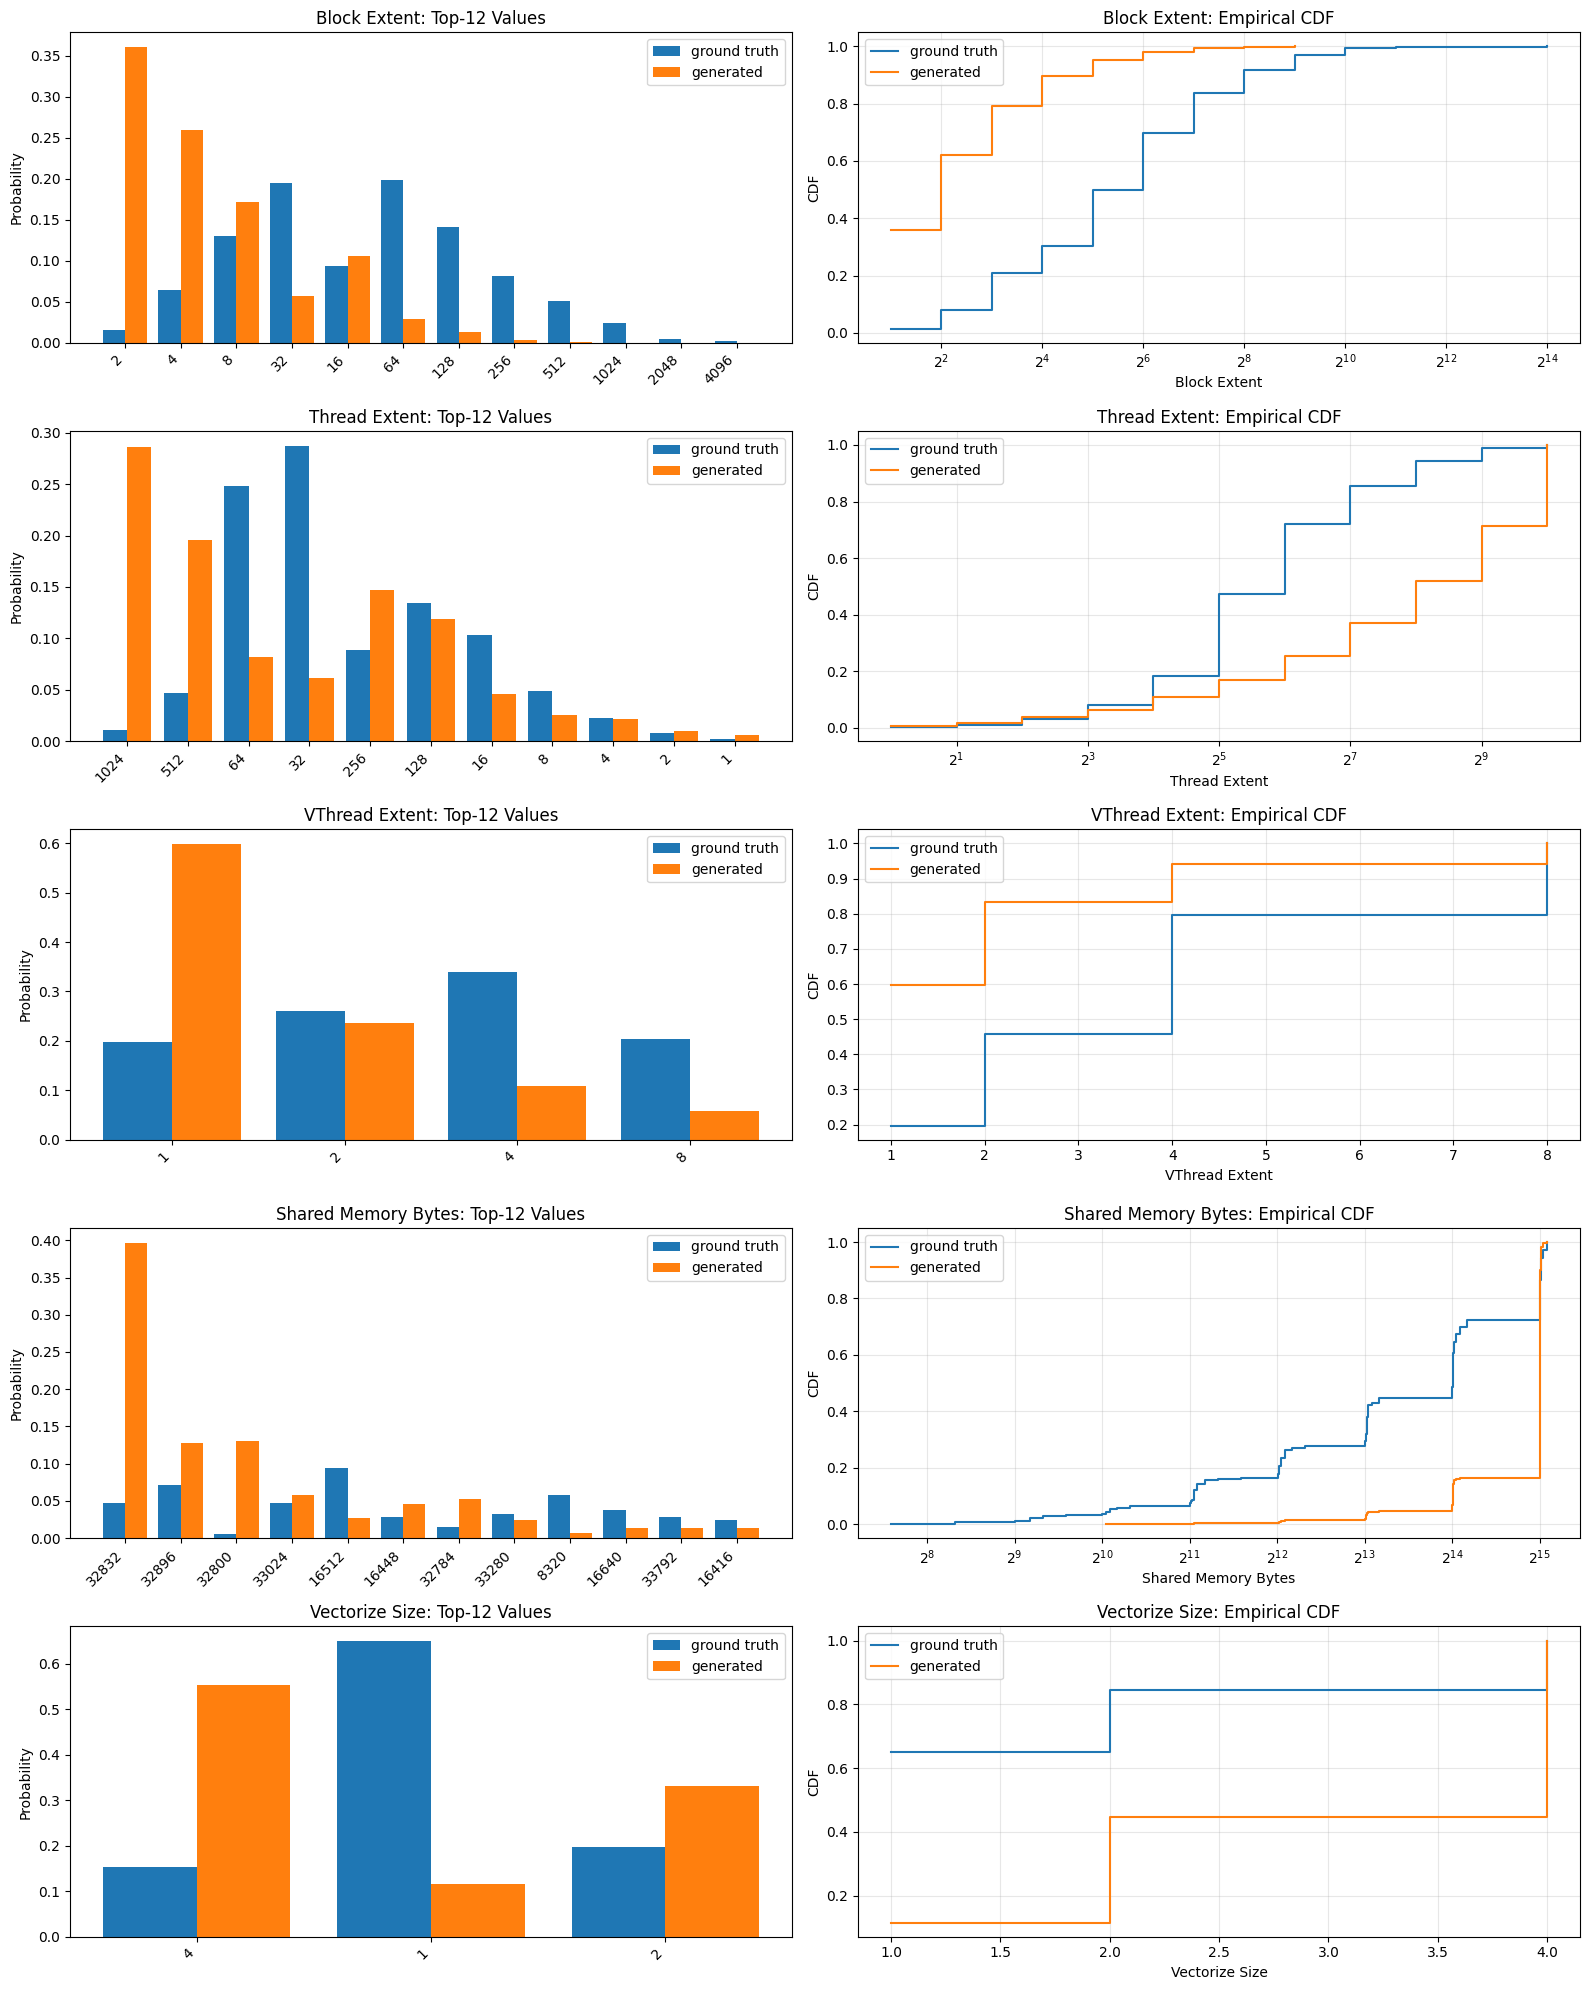

In [24]:
def maybe_set_log_scale(ax, values):
    values = [int(v) for v in values if int(v) > 0]
    if not values:
        return
    vmin = min(values)
    vmax = max(values)
    if vmax >= max(64, vmin * 8):
        ax.set_xscale('log', base=2)


def plot_metric_comparison(metric, top_k=12, left_ax=None, right_ax=None):
    gt_counter = Counter(gt_df[metric])
    gen_counter = Counter(gen_df[metric])
    gt_prob = normalize_counter(gt_counter)
    gen_prob = normalize_counter(gen_counter)
    combined = gt_counter + gen_counter
    top_values = [value for value, _ in combined.most_common(top_k)]

    if left_ax is not None:
        xpos = range(len(top_values))
        left_ax.bar([x - 0.2 for x in xpos], [gt_prob.get(v, 0.0) for v in top_values], width=0.4, label='ground truth')
        left_ax.bar([x + 0.2 for x in xpos], [gen_prob.get(v, 0.0) for v in top_values], width=0.4, label='generated')
        left_ax.set_title(f"{METRIC_LABELS[metric]}: Top-{top_k} Values")
        left_ax.set_xticks(list(xpos))
        left_ax.set_xticklabels([str(v) for v in top_values], rotation=45, ha='right')
        left_ax.set_ylabel('Probability')
        left_ax.legend()

    if right_ax is not None:
        gt_series = pd.Series(gt_df[metric]).value_counts().sort_index().cumsum() / len(gt_df)
        gen_series = pd.Series(gen_df[metric]).value_counts().sort_index().cumsum() / len(gen_df)
        right_ax.step(gt_series.index, gt_series.values, where='post', label='ground truth')
        right_ax.step(gen_series.index, gen_series.values, where='post', label='generated')
        right_ax.set_title(f"{METRIC_LABELS[metric]}: Empirical CDF")
        right_ax.set_ylabel('CDF')
        right_ax.set_xlabel(METRIC_LABELS[metric])
        maybe_set_log_scale(right_ax, list(gt_series.index) + list(gen_series.index))
        right_ax.grid(alpha=0.3)
        right_ax.legend()


fig, axes = plt.subplots(len(METRIC_ORDER), 2, figsize=(16, 4 * len(METRIC_ORDER)))
for row_idx, metric in enumerate(METRIC_ORDER):
    plot_metric_comparison(metric, top_k=12, left_ax=axes[row_idx, 0], right_ax=axes[row_idx, 1])
plt.tight_layout()
plt.show()